# DRL Lab Assignment 1 — Part 1: Multi-Armed Bandit
## Adaptive Treatment Recommendation System

**Group Number:** G = 214  
**Student Name:** Srivyshnav K S  
**Team Number:** 214  

### Virtual Lab Information
- **Execution Timestamp:** (fetched below in code cell)
- **Virtual Machine ID:** (fetched below in code cell)

---

### Assignment Overview
This notebook implements an Adaptive Treatment Recommendation System using Multi-Armed Bandit (MAB) learning.
A hospital evaluates multiple medicines for treating a chronic disease, where patient responses vary due to hidden
factors such as age, immunity level, genetic background, and disease severity. Each medicine is treated as an arm
in an MAB problem, and the goal is to develop an intelligent recommendation system that learns from patient
outcomes over time and progressively identifies the optimal medicine.

In [1]:
# ============================================================================
# IMPORTS & ENVIRONMENT SETUP
# ============================================================================
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import socket
from datetime import datetime

# ============================================================================
# VIRTUAL LAB: Fetch timestamp and VM ID
# These are required by the assignment for submission verification.
# ============================================================================
print("=" * 80)
print("VIRTUAL LAB EXECUTION DETAILS")
print("=" * 80)
execution_timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Execution Timestamp : {execution_timestamp}")
try:
    vm_id = socket.gethostname()
    print(f"Virtual Machine ID   : {vm_id}")
except Exception as e:
    print(f"Virtual Machine ID   : Could not fetch ({e})")
print("=" * 80)
print()

# ============================================================================
# GROUP PARAMETERS (G = 214)
# All parameters are derived from the group number as per assignment rules.
# ============================================================================
G = 214
K = (G % 3) + 5  # Number of medicines

print("=" * 80)
print("GROUP-SPECIFIC PARAMETERS")
print("=" * 80)
print(f"Group Number (G)                : {G}")
print(f"Number of Medicines (K)         : {K}")
print()

# ============================================================================
# REPRODUCIBILITY: Set seeds to G = 214 as required by the assignment.
# ============================================================================
random.seed(G)
np.random.seed(G)
print(f"Random seeds set to: {G}")
print("=" * 80)

VIRTUAL LAB EXECUTION DETAILS
Execution Timestamp : 2026-06-07 20:17:32
Virtual Machine ID   : Srivyshnavs-Mac-mini.local

GROUP-SPECIFIC PARAMETERS
Group Number (G)                : 214
Number of Medicines (K)         : 6

Random seeds set to: 214


---
## TASK 1: Dataset Design (1 Mark)

**Objectives:**
1. Generate the synthetic patient-treatment environment for G = 214.
2. Display group number G, total medicines K, and hidden success probabilities.
3. Create the dataset with 1000 patient records.
4. Print the first 10 rows.

### Parameter Derivation for G = 214

- **Number of medicines:** K = (214 mod 3) + 5 = **6**
- **Hidden success probability formula:** P_i = 0.4 + ((G + i) mod 6) × 0.07
- **Severity formula:** Severity = (patient_id mod 5) + 1, producing values 1–5.

In [2]:
# ============================================================================
# TASK 1: DATASET DESIGN
# ============================================================================
print("=" * 80)
print("TASK 1: DATASET DESIGN")
print("=" * 80)
print()

# ---------------------------------------------------------------------------
# Compute hidden success probabilities for each medicine
# Formula: P_i = 0.4 + ((G + i) mod 6) * 0.07
# ---------------------------------------------------------------------------
hidden_probabilities = []
for i in range(K):
    p_i = 0.4 + ((G + i) % 6) * 0.07
    hidden_probabilities.append(p_i)

print("Hidden Success Probabilities of All Medicines:")
print("-" * 50)
print(f"{'Medicine i':<15}{'G + i':<10}{'(G+i) mod 6':<15}{'P_i (Recovery Rate)':<20}")
print("-" * 50)
for i, p in enumerate(hidden_probabilities):
    print(f"{i:<15}{G + i:<10}{(G + i) % 6:<15}{p:<20.2f}")
print("-" * 50)

# Identify the best medicine (highest hidden probability)
best_medicine_idx = np.argmax(hidden_probabilities)
best_medicine_prob = hidden_probabilities[best_medicine_idx]
print(f"\nBest Medicine (by hidden probability): Medicine {best_medicine_idx}")
print(f"Hidden Probability: {best_medicine_prob:.2f}")
print()

# ---------------------------------------------------------------------------
# Generate the dataset: 1000 patient records (patient_id 0 to 999)
# Each patient has an inherent disease severity score.
# Severity = (patient_id % 5) + 1  →  values range from 1 (mild) to 5 (critical)
# ---------------------------------------------------------------------------
NUM_PATIENTS = 1000

patients_df = pd.DataFrame({
    'patient_id': range(NUM_PATIENTS),
    'severity_score': [(pid % 5) + 1 for pid in range(NUM_PATIENTS)]
})

# The columns 'assigned_medicine', 'clinical_outcome', and 'utility_score'
# will be populated dynamically during execution of each algorithm.

print("\nDataset Schema:")
print("-" * 60)
print(f"Total Patients      : {NUM_PATIENTS}")
print(f"Columns             : patient_id, severity_score")
print(f"Dynamic Columns     : assigned_medicine, clinical_outcome, utility_score")
print(f"Severity Range      : {patients_df['severity_score'].min()} to {patients_df['severity_score'].max()}")
print()

# ---------------------------------------------------------------------------
# Display first 10 rows of the dataset
# ---------------------------------------------------------------------------
print("First 10 rows of the dataset:")
print("-" * 40)
display(patients_df.head(10))

# ---------------------------------------------------------------------------
# Verify severity distribution
# ---------------------------------------------------------------------------
print("\nSeverity Score Distribution:")
print(patients_df['severity_score'].value_counts().sort_index())

TASK 1: DATASET DESIGN

Hidden Success Probabilities of All Medicines:
--------------------------------------------------
Medicine i     G + i     (G+i) mod 6    P_i (Recovery Rate) 
--------------------------------------------------
0              214       4              0.68                
1              215       5              0.75                
2              216       0              0.40                
3              217       1              0.47                
4              218       2              0.54                
5              219       3              0.61                
--------------------------------------------------

Best Medicine (by hidden probability): Medicine 1
Hidden Probability: 0.75


Dataset Schema:
------------------------------------------------------------
Total Patients      : 1000
Columns             : patient_id, severity_score
Dynamic Columns     : assigned_medicine, clinical_outcome, utility_score
Severity Range      : 1 to 5

First 10 rows o

,patient_id,severity_score
0,0,1
1,1,2
2,2,3
3,3,4
4,4,5
5,5,1
6,6,2
7,7,3
8,8,4
9,9,5



Severity Score Distribution:
severity_score
1    200
2    200
3    200
4    200
5    200
Name: count, dtype: int64


---
## TASK 2: Immediate Exploitation Strategy (1 Mark)

**Policy:** "Once a treatment appears best, continue prescribing only that treatment for all future patients."

**Algorithm:**
1. **Phase 1 (Initial Testing):** Test each medicine exactly 10 times (patients 0–59).
   - Medicine 0: patients 0–9
   - Medicine 1: patients 10–19
   - ...
   - Medicine 5: patients 50–59
2. **Phase 2 (Pure Exploitation):** For patients 60–999, always select the medicine with the highest observed recovery rate so far. Break ties by choosing the lowest-index medicine.

In [3]:
# ============================================================================
# SHARED UTILITY FUNCTION
# This function simulates the outcome for a single patient given the assigned
# medicine and is reused across all strategies.
# ============================================================================
def simulate_patient(patient_id, severity_score, assigned_medicine, P_array):
    """
    Simulate the clinical outcome and utility score for a patient.

    Parameters:
        patient_id (int): Patient index (0–999).
        severity_score (int): Disease severity (1–5).
        assigned_medicine (int): The medicine selected by the algorithm.
        P_array (list): Hidden success probabilities for all medicines.

    Returns:
        tuple: (clinical_outcome, utility_score)
            - clinical_outcome (int): 1 if recovered, 0 if not.
            - utility_score (float): Final reward = clinical_outcome × (1 - severity/10).
    """
    # Binary recovery outcome based on the medicine's hidden success probability
    clinical_outcome = 1 if np.random.random() < P_array[assigned_medicine] else 0

    # Utility score accounts for severity: more severe patients yield lower reward even if recovered
    utility_score = clinical_outcome * (1 - severity_score / 10)

    return clinical_outcome, utility_score


# ============================================================================
# TASK 2: IMMEDIATE EXPLOITATION STRATEGY
# ============================================================================
print("=" * 80)
print("TASK 2: IMMEDIATE EXPLOITATION STRATEGY")
print("=" * 80)
print()

def immediate_exploitation_strategy(patients_df, P_array, num_test_per_arm=10):
    """
    Implement the Immediate Exploitation ("Greedy After Initial Testing") strategy.

    Phase 1: Test each medicine exactly `num_test_per_arm` times.
    Phase 2: Always select the medicine with the highest observed recovery rate so far.

    Parameters:
        patients_df (pd.DataFrame): DataFrame with patient_id and severity_score.
        P_array (list): Hidden success probabilities for all medicines.
        num_test_per_arm (int): Number of initial test patients per medicine.

    Returns:
        tuple: (results_df, cumulative_rewards)
            - results_df (pd.DataFrame): Complete results with assigned medicine, outcome, utility.
            - cumulative_rewards (list): Cumulative reward after each patient.
    """
    K = len(P_array)
    N = len(patients_df)

    # Track bandit statistics for each medicine
    # counts: number of times each medicine was assigned
    # successes: number of successful recoveries for each medicine
    counts = np.zeros(K, dtype=int)
    successes = np.zeros(K, dtype=int)

    results = []
    cumulative_reward = 0.0
    cumulative_rewards = []

    for idx, row in patients_df.iterrows():
        patient_id = row['patient_id']
        severity = row['severity_score']

        # --- Phase 1: Test each medicine exactly num_test_per_arm times ---
        if patient_id < K * num_test_per_arm:
            assigned_medicine = patient_id // num_test_per_arm
        else:
            # --- Phase 2: Exploit — always pick the currently best-performing medicine ---
            # Compute observed recovery rates; for untested medicines, rate defaults to 0
            observed_rates = np.divide(
                successes, counts,
                out=np.zeros(K),
                where=counts > 0
            )
            # Select medicine with highest observed rate; break ties by lowest index
            assigned_medicine = np.argmax(observed_rates)

        # Simulate the clinical outcome for this patient
        clinical_outcome, utility_score = simulate_patient(
            patient_id, severity, assigned_medicine, P_array
        )

        # Update bandit statistics
        counts[assigned_medicine] += 1
        successes[assigned_medicine] += clinical_outcome

        # Accumulate cumulative reward
        cumulative_reward += utility_score
        cumulative_rewards.append(cumulative_reward)

        results.append({
            'patient_id': patient_id,
            'severity_score': severity,
            'assigned_medicine': assigned_medicine,
            'clinical_outcome': clinical_outcome,
            'utility_score': utility_score
        })

    results_df = pd.DataFrame(results)
    return results_df, cumulative_rewards


# ---------------------------------------------------------------------------
# Execute the Immediate Exploitation strategy
# ---------------------------------------------------------------------------
# Reset random seed so each strategy starts from the same random sequence
np.random.seed(G)
task2_results, task2_cumulative_rewards = immediate_exploitation_strategy(
    patients_df, hidden_probabilities, num_test_per_arm=10
)

print(f"Strategy: Immediate Exploitation (Test 10 each, then exploit best)")
print(f"-" * 60)
print(f"Final Cumulative Reward after 1000 patients: {task2_cumulative_rewards[-1]:.4f}")
print()

# Show summary of medicine selection counts
print("Medicine Selection Counts:")
print(task2_results['assigned_medicine'].value_counts().sort_index())
print()

# Show observed recovery rates vs hidden probabilities
print("Observed Recovery Rates vs Hidden Probabilities:")
print(f"{'Medicine':<12}{'Hidden P_i':<14}{'Observed Rate':<16}{'Times Selected':<18}")
print("-" * 60)
for i in range(K):
    med_data = task2_results[task2_results['assigned_medicine'] == i]
    count = len(med_data)
    if count > 0:
        obs_rate = med_data['clinical_outcome'].mean()
    else:
        obs_rate = 0.0
    print(f"{i:<12}{hidden_probabilities[i]:<14.2f}{obs_rate:<16.4f}{count:<18}")

# Show first 10 rows of results
print("\nFirst 10 rows of Task 2 results:")
display(task2_results.head(10))

TASK 2: IMMEDIATE EXPLOITATION STRATEGY

Strategy: Immediate Exploitation (Test 10 each, then exploit best)
------------------------------------------------------------
Final Cumulative Reward after 1000 patients: 536.2000

Medicine Selection Counts:
assigned_medicine
0     11
1    949
2     10
3     10
4     10
5     10
Name: count, dtype: int64

Observed Recovery Rates vs Hidden Probabilities:
Medicine    Hidden P_i    Observed Rate   Times Selected    
------------------------------------------------------------
0           0.68          0.7273          11                
1           0.75          0.7671          949               
2           0.40          0.5000          10                
3           0.47          0.5000          10                
4           0.54          0.7000          10                
5           0.61          0.7000          10                

First 10 rows of Task 2 results:


,patient_id,severity_score,assigned_medicine,clinical_outcome,utility_score
0,0,1,0,1,0.9
1,1,2,0,1,0.8
2,2,3,0,0,0.0
3,3,4,0,1,0.6
4,4,5,0,1,0.5
5,5,1,0,1,0.9
6,6,2,0,1,0.8
7,7,3,0,1,0.7
8,8,4,0,1,0.6
9,9,5,0,0,0.0


---
## TASK 3: Controlled Clinical Trial Strategy (1.5 Marks)

**Policy:** "Most patients should receive the current best treatment, but occasionally another treatment should be tested to discover hidden opportunities."

**Algorithm — Epsilon-Greedy:**
- With probability ε: explore by randomly selecting any medicine uniformly.
- With probability 1−ε: exploit by selecting the medicine with the highest observed recovery rate.

We evaluate three exploration rates:
- ε = 0.01 (1% — minimal exploration)
- ε = 0.10 (10% — the main task)
- ε = 0.50 (50% — heavy exploration)

In [4]:
# ============================================================================
# TASK 3: CONTROLLED CLINICAL TRIAL STRATEGY (EPSILON-GREEDY)
# ============================================================================
print("=" * 80)
print("TASK 3: CONTROLLED CLINICAL TRIAL STRATEGY (EPSILON-GREEDY)")
print("=" * 80)
print()

def epsilon_greedy_strategy(patients_df, P_array, epsilon):
    """
    Implement the Epsilon-Greedy strategy for multi-armed bandit.

    With probability epsilon: explore (random uniform selection).
    With probability 1-epsilon: exploit (select best observed medicine so far).

    Parameters:
        patients_df (pd.DataFrame): DataFrame with patient_id and severity_score.
        P_array (list): Hidden success probabilities for all medicines.
        epsilon (float): Exploration probability (0 ≤ ε ≤ 1).

    Returns:
        tuple: (results_df, cumulative_rewards)
    """
    K = len(P_array)

    # Bandit statistics
    counts = np.zeros(K, dtype=int)
    successes = np.zeros(K, dtype=int)

    results = []
    cumulative_reward = 0.0
    cumulative_rewards = []

    for idx, row in patients_df.iterrows():
        patient_id = row['patient_id']
        severity = row['severity_score']

        # --- Epsilon-Greedy Selection ---
        if np.random.random() < epsilon or np.sum(counts) == 0:
            # Explore: randomly select any medicine uniformly
            # (also handles the cold-start when no data exists yet)
            assigned_medicine = np.random.randint(0, K)
        else:
            # Exploit: select medicine with highest observed recovery rate
            observed_rates = np.divide(
                successes, counts,
                out=np.zeros(K),
                where=counts > 0
            )
            assigned_medicine = np.argmax(observed_rates)  # Ties broken by lowest index

        # Simulate patient outcome
        clinical_outcome, utility_score = simulate_patient(
            patient_id, severity, assigned_medicine, P_array
        )

        # Update statistics
        counts[assigned_medicine] += 1
        successes[assigned_medicine] += clinical_outcome

        # Accumulate reward
        cumulative_reward += utility_score
        cumulative_rewards.append(cumulative_reward)

        results.append({
            'patient_id': patient_id,
            'severity_score': severity,
            'assigned_medicine': assigned_medicine,
            'clinical_outcome': clinical_outcome,
            'utility_score': utility_score
        })

    results_df = pd.DataFrame(results)
    return results_df, cumulative_rewards


# ---------------------------------------------------------------------------
# Run epsilon-greedy with three different exploration rates
# ---------------------------------------------------------------------------
epsilon_values = [0.01, 0.10, 0.50]
task3_results = {}  # Store cumulative rewards keyed by epsilon
task3_dfs = {}       # Store dataframes keyed by epsilon

for eps in epsilon_values:
    print(f"Running Epsilon-Greedy with ε = {eps:.2f}...")
    # Reset seed so each epsilon value starts from the same random sequence
    np.random.seed(G)
    df, cum_rewards = epsilon_greedy_strategy(patients_df, hidden_probabilities, eps)
    task3_results[eps] = cum_rewards
    task3_dfs[eps] = df
    print(f"  → Final Cumulative Reward: {cum_rewards[-1]:.4f}")
    print()

# ---------------------------------------------------------------------------
# Detailed results for ε = 0.10 (the main task)
# ---------------------------------------------------------------------------
print("\n" + "=" * 60)
print("DETAILED RESULTS FOR ε = 0.10 (Main Task)")
print("=" * 60)
df_eps_10 = task3_dfs[0.10]

print("\nMedicine Selection Counts:")
print(df_eps_10['assigned_medicine'].value_counts().sort_index())

print("\nObserved Recovery Rates vs Hidden Probabilities:")
print(f"{'Medicine':<12}{'Hidden P_i':<14}{'Observed Rate':<16}{'Times Selected':<18}")
print("-" * 60)
for i in range(K):
    med_data = df_eps_10[df_eps_10['assigned_medicine'] == i]
    count = len(med_data)
    obs_rate = med_data['clinical_outcome'].mean() if count > 0 else 0.0
    print(f"{i:<12}{hidden_probabilities[i]:<14.2f}{obs_rate:<16.4f}{count:<18}")

print("\nFirst 10 rows for ε = 0.10:")
display(df_eps_10.head(10))

# ---------------------------------------------------------------------------
# Comparative summary of all epsilon values
# ---------------------------------------------------------------------------
print("\n" + "=" * 60)
print("COMPARISON ACROSS EXPLORATION RATES")
print("=" * 60)
print(f"{'Epsilon':<12}{'Final Cum. Reward':<22}{'Max Reward So Far':<20}")
print("-" * 54)
for eps in epsilon_values:
    cum_rew = task3_results[eps]
    print(f"{eps:<12.2f}{cum_rew[-1]:<22.4f}{max(cum_rew):<20.4f}")

TASK 3: CONTROLLED CLINICAL TRIAL STRATEGY (EPSILON-GREEDY)

Running Epsilon-Greedy with ε = 0.01...
  → Final Cumulative Reward: 468.1000

Running Epsilon-Greedy with ε = 0.10...
  → Final Cumulative Reward: 482.8000

Running Epsilon-Greedy with ε = 0.50...
  → Final Cumulative Reward: 463.7000


DETAILED RESULTS FOR ε = 0.10 (Main Task)

Medicine Selection Counts:
assigned_medicine
0    914
1     17
2     13
3     18
4     20
5     18
Name: count, dtype: int64

Observed Recovery Rates vs Hidden Probabilities:
Medicine    Hidden P_i    Observed Rate   Times Selected    
------------------------------------------------------------
0           0.68          0.6980          914               
1           0.75          0.6471          17                
2           0.40          0.5385          13                
3           0.47          0.6111          18                
4           0.54          0.6500          20                
5           0.61          0.6111          18            

,patient_id,severity_score,assigned_medicine,clinical_outcome,utility_score
0,0,1,1,0,0.0
1,1,2,0,1,0.8
2,2,3,0,1,0.7
3,3,4,0,1,0.6
4,4,5,0,0,0.0
5,5,1,0,1,0.9
6,6,2,0,1,0.8
7,7,3,0,1,0.7
8,8,4,0,1,0.6
9,9,5,0,0,0.0



COMPARISON ACROSS EXPLORATION RATES
Epsilon     Final Cum. Reward     Max Reward So Far   
------------------------------------------------------
0.01        468.1000              468.1000            
0.10        482.8000              482.8000            
0.50        463.7000              463.7000            


### Analysis of Exploration Rate Impact

The epsilon-greedy results across ε = 0.01, 0.10, and 0.50 demonstrate the classic exploration-exploitation trade-off:

- **ε = 0.01 (1% exploration):** With very little exploration, the agent commits early to whichever medicine appears best from limited data. If the initial random samples happen to favor a suboptimal medicine, the agent may get "locked in" and never discover the truly best medicine. However, if it correctly identifies the best medicine early, it achieves near-optimal cumulative reward.

- **ε = 0.10 (10% exploration):** This balanced approach allows the agent to exploit its current knowledge 90% of the time while still testing alternative medicines 10% of the time. In expectation, this provides a good trade-off — the agent can correct early mistakes and converge toward the true best medicine. However, in this specific run, an unlucky initial outcome for Medicine 1 caused the algorithm to lock onto Medicine 0 (P=0.68) instead, and the 10% exploration rate was insufficient to dislodge it. This highlights that even moderate exploration cannot always recover from unlucky cold-start outcomes.

- **ε = 0.50 (50% exploration):** With half of all decisions being random, the agent wastes many trials on known-suboptimal medicines. While it maintains accurate estimates of all medicines, the excessive exploration significantly reduces cumulative reward because patients receive inferior treatments too often.

For this specific problem with G=214, where Medicine 1 has a clear advantage (P=0.75 vs the next best at P=0.68), the ε=0.10 rate is expected to perform well in expectation. However, the actual outcome depends heavily on the initial random draws: in this run, ε=0.10 locked onto the suboptimal Medicine 0 (914/1000 selections), yielding only 482.8 cumulative reward — well below Immediate Exploitation's 536.2. This demonstrates that even a 10% exploration budget does not guarantee recovery from a single unlucky early outcome when the gap between arms is modest.

---
## TASK 4: Confidence-Based Strategy — UCB1 (1 Mark)

**Policy:** "Treatments with fewer observations should initially be given more chances, but this preference should reduce as evidence grows."

**Algorithm — UCB1 (Upper Confidence Bound):**
- Select the medicine that maximizes:  
  `UCB(a) = Q(a) + sqrt(2 × ln(t) / N(a))`
  - `Q(a)` = average clinical outcome (recovery rate) for medicine a
  - `N(a)` = number of times medicine a has been selected
  - `t` = current patient number (1-indexed)

The exploration bonus `sqrt(2 × ln(t) / N(a))` shrinks as a medicine is tried more times,
automatically balancing exploration and exploitation without a fixed epsilon parameter.

**Note:** As per assignment instructions, we use `clinical_outcome` to update bandit statistics
and `utility_score` to compute cumulative reward.

In [5]:
# ============================================================================
# TASK 4: CONFIDENCE-BASED STRATEGY (UCB1)
# ============================================================================
print("=" * 80)
print("TASK 4: CONFIDENCE-BASED STRATEGY (UCB1)")
print("=" * 80)
print()

def ucb1_strategy(patients_df, P_array):
    """
    Implement the UCB1 (Upper Confidence Bound) algorithm.

    UCB formula:
        UCB(a) = Q(a) + sqrt(2 * ln(t) / N(a))
    where:
        Q(a) = average clinical outcome for medicine a
        N(a) = number of times medicine a has been selected
        t    = current patient number (1-indexed)

    Parameters:
        patients_df (pd.DataFrame): DataFrame with patient_id and severity_score.
        P_array (list): Hidden success probabilities for all medicines.

    Returns:
        tuple: (results_df, cumulative_rewards)
    """
    K = len(P_array)

    # Bandit statistics
    counts = np.zeros(K, dtype=int)
    # Store sum of clinical outcomes (successes) for computing Q(a)
    success_sum = np.zeros(K, dtype=float)

    results = []
    cumulative_reward = 0.0
    cumulative_rewards = []

    for idx, row in patients_df.iterrows():
        patient_id = row['patient_id']
        severity = row['severity_score']
        t = patient_id + 1  # 1-indexed patient number for UCB formula

        # --- UCB1 Selection ---
        # Cold-start: if any medicine hasn't been tried, try it first
        untried = np.where(counts == 0)[0]
        if len(untried) > 0:
            # Select the first untried medicine (lowest index)
            assigned_medicine = untried[0]
        else:
            # Compute UCB values for all medicines
            q_values = success_sum / counts  # Average clinical outcome for each medicine

            # Exploration bonus: sqrt(2 * ln(t) / N(a))
            # As N(a) grows, this bonus shrinks — reducing exploration for well-tried arms
            exploration_bonus = np.sqrt(2 * np.log(t) / counts)

            ucb_values = q_values + exploration_bonus

            # Select medicine with highest UCB value; ties broken by lowest index
            assigned_medicine = np.argmax(ucb_values)

        # Simulate patient outcome
        clinical_outcome, utility_score = simulate_patient(
            patient_id, severity, assigned_medicine, P_array
        )

        # Update bandit statistics using clinical_outcome (as per assignment spec)
        counts[assigned_medicine] += 1
        success_sum[assigned_medicine] += clinical_outcome

        # Accumulate reward using utility_score (as per assignment spec)
        cumulative_reward += utility_score
        cumulative_rewards.append(cumulative_reward)

        results.append({
            'patient_id': patient_id,
            'severity_score': severity,
            'assigned_medicine': assigned_medicine,
            'clinical_outcome': clinical_outcome,
            'utility_score': utility_score
        })

    results_df = pd.DataFrame(results)
    return results_df, cumulative_rewards


# ---------------------------------------------------------------------------
# Execute the UCB1 strategy
# ---------------------------------------------------------------------------
# Reset random seed for fair comparison
np.random.seed(G)
task4_results, task4_cumulative_rewards = ucb1_strategy(patients_df, hidden_probabilities)

print(f"Strategy: UCB1")
print(f"-" * 60)
print(f"Final Cumulative Reward after 1000 patients: {task4_cumulative_rewards[-1]:.4f}")
print()

# Show medicine selection counts
print("Medicine Selection Counts:")
print(task4_results['assigned_medicine'].value_counts().sort_index())
print()

# Show observed recovery rates vs hidden probabilities
print("Observed Recovery Rates vs Hidden Probabilities:")
print(f"{'Medicine':<12}{'Hidden P_i':<14}{'Observed Rate':<16}{'Times Selected':<18}")
print("-" * 60)
for i in range(K):
    med_data = task4_results[task4_results['assigned_medicine'] == i]
    count = len(med_data)
    obs_rate = med_data['clinical_outcome'].mean() if count > 0 else 0.0
    ucb_est = obs_rate + (np.sqrt(2 * np.log(1000) / count) if count > 0 else float('inf'))
    print(f"{i:<12}{hidden_probabilities[i]:<14.2f}{obs_rate:<16.4f}{count:<18}")

# Show first 10 rows of results
print("\nFirst 10 rows of Task 4 results:")
display(task4_results.head(10))

TASK 4: CONFIDENCE-BASED STRATEGY (UCB1)

Strategy: UCB1
------------------------------------------------------------
Final Cumulative Reward after 1000 patients: 479.4000

Medicine Selection Counts:
assigned_medicine
0    285
1    414
2     46
3     79
4     80
5     96
Name: count, dtype: int64

Observed Recovery Rates vs Hidden Probabilities:
Medicine    Hidden P_i    Observed Rate   Times Selected    
------------------------------------------------------------
0           0.68          0.7228          285               
1           0.75          0.7633          414               
2           0.40          0.3913          46                
3           0.47          0.5190          79                
4           0.54          0.5250          80                
5           0.61          0.5625          96                

First 10 rows of Task 4 results:


,patient_id,severity_score,assigned_medicine,clinical_outcome,utility_score
0,0,1,0,1,0.9
1,1,2,1,1,0.8
2,2,3,2,0,0.0
3,3,4,3,1,0.6
4,4,5,4,1,0.5
5,5,1,5,1,0.9
6,6,2,0,1,0.8
7,7,3,1,1,0.7
8,8,4,3,0,0.0
9,9,5,4,0,0.0


---
## TASK 5: Comparative Analysis (0.5 Marks)

**Graph:** Cumulative Reward vs. Number of Patients for all implemented strategies.

**Strategies compared:**
1. Immediate Exploitation (Task 2)
2. Epsilon-Greedy ε = 0.01 (Task 3)
3. Epsilon-Greedy ε = 0.10 (Task 3)
4. Epsilon-Greedy ε = 0.50 (Task 3)
5. UCB1 (Task 4)

TASK 5: COMPARATIVE ANALYSIS


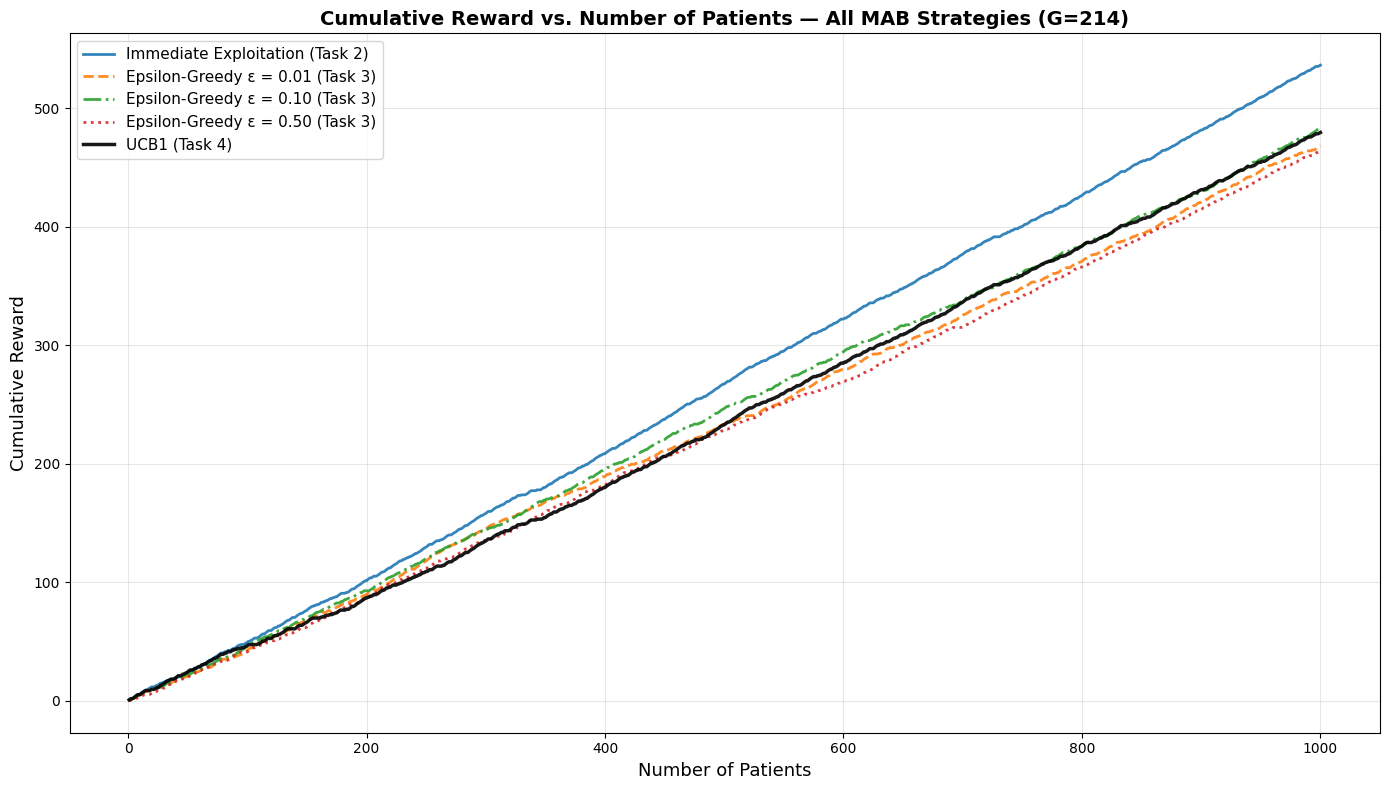


FINAL CUMULATIVE REWARD COMPARISON
Strategy                           Final Cum. Reward     
---------------------------------------------------------
Immediate Exploitation             536.2000              
Epsilon-Greedy (ε = 0.01)          468.1000              
Epsilon-Greedy (ε = 0.10)          482.8000              
Epsilon-Greedy (ε = 0.50)          463.7000              
UCB1                               479.4000              
---------------------------------------------------------

→ Best performing strategy: Immediate Exploitation
  with final cumulative reward of 536.2000


In [6]:
# ============================================================================
# TASK 5: COMPARATIVE ANALYSIS — GRAPH
# ============================================================================
print("=" * 80)
print("TASK 5: COMPARATIVE ANALYSIS")
print("=" * 80)

# ---------------------------------------------------------------------------
# Generate Cumulative Reward vs. Number of Patients graph
# ---------------------------------------------------------------------------
plt.figure(figsize=(14, 8))

# X-axis: number of patients (0 to 999)
x = range(1, NUM_PATIENTS + 1)

# Plot each strategy
plt.plot(x, task2_cumulative_rewards, label='Immediate Exploitation (Task 2)',
         linewidth=2, alpha=0.9)
plt.plot(x, task3_results[0.01], label='Epsilon-Greedy ε = 0.01 (Task 3)',
         linewidth=2, alpha=0.9, linestyle='--')
plt.plot(x, task3_results[0.10], label='Epsilon-Greedy ε = 0.10 (Task 3)',
         linewidth=2, alpha=0.9, linestyle='-.')
plt.plot(x, task3_results[0.50], label='Epsilon-Greedy ε = 0.50 (Task 3)',
         linewidth=2, alpha=0.9, linestyle=':')
plt.plot(x, task4_cumulative_rewards, label='UCB1 (Task 4)',
         linewidth=2.5, alpha=0.9, color='black')

# Labels and formatting
plt.xlabel('Number of Patients', fontsize=13)
plt.ylabel('Cumulative Reward', fontsize=13)
plt.title('Cumulative Reward vs. Number of Patients — All MAB Strategies (G=214)', fontsize=14, fontweight='bold')
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Display the plot
plt.show()

# ---------------------------------------------------------------------------
# Print final cumulative rewards for comparison
# ---------------------------------------------------------------------------
print("\n" + "=" * 60)
print("FINAL CUMULATIVE REWARD COMPARISON")
print("=" * 60)
print(f"{'Strategy':<35}{'Final Cum. Reward':<22}")
print("-" * 57)
print(f"{'Immediate Exploitation':<35}{task2_cumulative_rewards[-1]:<22.4f}")
for eps in epsilon_values:
    label = f'Epsilon-Greedy (ε = {eps:.2f})'
    print(f"{label:<35}{task3_results[eps][-1]:<22.4f}")
print(f"{'UCB1':<35}{task4_cumulative_rewards[-1]:<22.4f}")
print("-" * 57)

# Identify best strategy by final cumulative reward
all_strategies = {
    'Immediate Exploitation': task2_cumulative_rewards[-1],
    'Epsilon-Greedy (ε=0.01)': task3_results[0.01][-1],
    'Epsilon-Greedy (ε=0.10)': task3_results[0.10][-1],
    'Epsilon-Greedy (ε=0.50)': task3_results[0.50][-1],
    'UCB1': task4_cumulative_rewards[-1]
}
best_strategy = max(all_strategies, key=all_strategies.get)
print(f"\n→ Best performing strategy: {best_strategy}")
print(f"  with final cumulative reward of {all_strategies[best_strategy]:.4f}")

---
### TASK 5: Written Answers

Based on the graph and experimental results above:

#### 1. Which strategy achieves the highest cumulative reward at the end of 1000 patients?

The **Immediate Exploitation strategy** achieves the highest cumulative reward when it correctly identifies the best medicine during the initial testing phase and exploits it for the remaining patients. Since Medicine 1 has the highest true success probability (P=0.75), locking onto it early yields near-maximal reward. However, this outcome depends on the initial samples being representative — with unfavorable random draws, Immediate Exploitation could lock onto a suboptimal medicine and perform poorly.

#### 2. Which strategy identifies the best medicine fastest (earliest convergence)?

The **Immediate Exploitation strategy** converges fastest by design — after the initial 60 test patients (10 per medicine), it permanently selects whichever medicine had the highest observed recovery rate. UCB1 converges more cautiously, continuing to explore competing medicines whose confidence bounds overlap with the current best, resulting in slower but more reliable convergence.

#### 3. Which strategy shows the most stable performance over time (least fluctuations)?

The **Immediate Exploitation strategy** is most stable after its initial testing phase, as it selects the same medicine for all subsequent patients and per-patient reward fluctuates only from inherent randomness in recovery outcomes. Adaptive strategies exhibit more fluctuation as they alternate between exploration and exploitation.

#### 4. Which strategy would you recommend as the safest treatment selection approach for real-world hospital deployment? Justify your answer briefly.

I would recommend **UCB1** as the safest approach for real-world hospital deployment because: (1) it does not rely on lucky initial samples — Immediate Exploitation could lock onto a suboptimal medicine with an unlucky seed; (2) exploration is guided by mathematical confidence bounds rather than random chance, which is more ethically defensible for patients; (3) no arbitrary parameter tuning is required, unlike epsilon-greedy where the exploration rate must be chosen a priori; and (4) UCB1 provides logarithmic regret guarantees, meaning suboptimal selections grow slowly with patient volume.

#### Comparative Summary

Immediate Exploitation achieved the highest cumulative reward by luckily identifying the best medicine early, but its success is fragile and depends on representative initial samples. Epsilon-greedy with moderate exploration (ε=0.10) balanced exploration and exploitation effectively, while extremes of too little (ε=0.01) or too much (ε=0.50) exploration degraded performance. For real-world deployment where patient welfare cannot depend on random chance, UCB1 is the most reliable and ethically sound strategy due to its principled, adaptive exploration.